# Robust Regression Engine for House Price Prediction

# **Part A: Conceptual Foundation (Theory)**

### Q1. What is Regularization in Machine Learning? Why is it needed?

Answer:

Regularization is a technique used to prevent overfitting by adding a penalty term to the model's loss function. It discourages excessively large coefficient values and improves model generalization. It helps create simpler and more stable models that perform better on unseen data.

### Q2. Difference between Ridge Regression (L2) and Lasso Regression (L1)

Answer:
| Feature | Ridge (L2) | Lasso (L1) |
| :--- | :--- | :--- |
| **Penalty** | Squared coefficients | Absolute coefficients |
| **Feature Selection** | No | Yes |
| **Coefficients** | Shrinks toward zero | Can become exactly zero |
| **Best Use** | Multicollinearity | High dimensional datasets |

### Q3. What is Cross Validation and why is it important?

Answer:

Cross-validation is a resampling technique used to evaluate model performance on unseen data. The dataset is split into multiple folds, and the model is trained and tested multiple times. It provides a more reliable estimate of model performance and reduces bias caused by a single train-test split.

### Q4. Explain Cross Validation Techniques

**K-Fold Cross Validation**

Dataset is divided into K equal parts. One fold is used for validation while remaining folds are used for training. Process repeats K times.

**Stratified K-Fold**

Maintains target distribution in every fold. Mainly useful when data distribution is imbalanced.

**Leave-One-Out Cross Validation (LOOCV)**

Each observation becomes a validation set once. Very accurate but computationally expensive.

**Time Series Split**

Used for sequential data. Future values are never used to predict past values.

### Q5. Why are tree-based models less sensitive to feature scaling?

Tree algorithms split data based on thresholds rather than distance calculations. Since scaling does not affect feature ordering, Decision Trees and Random Forests work effectively without normalization.

# **Part B: Dataset Understanding & Preparation**

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


### Load Dataset

In [2]:
df = pd.read_csv("Advanced_Regression_HousePrice_Dataset.csv")

df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


### Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [4]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [5]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

### Handle sale_date

In [6]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month

df.drop('sale_date', axis=1, inplace=True)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   area_sqft         3800 non-null   int64  
 2   bedrooms          3800 non-null   int64  
 3   bathrooms         3800 non-null   int64  
 4   location_score    3800 non-null   float64
 5   property_age      3800 non-null   int64  
 6   distance_city_km  3800 non-null   float64
 7   near_school       3800 non-null   int64  
 8   near_metro        3800 non-null   int64  
 9   crime_rate_index  3800 non-null   float64
 10  house_price_inr   3800 non-null   int64  
 11  sale_year         3800 non-null   int32  
 12  sale_month        3800 non-null   int32  
dtypes: float64(3), int32(2), int64(8)
memory usage: 356.4 KB


### Drop Unnecessary Columns

In [8]:
df.drop(['property_id'], axis=1, inplace=True)

In [9]:
df.head()

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr,sale_year,sale_month
0,2181,6,4,8.1,21,3.8,0,0,4.84,35154898,2014,1
1,2383,5,4,5.3,28,10.9,1,1,2.89,26710893,2019,12
2,1047,3,3,5.9,7,27.5,0,1,4.04,11216242,2016,10
3,1753,4,3,7.0,27,12.1,0,0,3.28,21984310,2013,3
4,1728,4,4,10.0,32,1.4,0,1,3.84,25080429,2013,7


## 6. Identify features and target variable.

In [10]:
X = df.drop('house_price_inr', axis=1)
y = df['house_price_inr']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (3800, 11)
Target Shape: (3800,)


## 7. Perform a train-test split.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 8. Apply basic preprocessing (scaling where required).

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Part C: Regularized Linear Models**

## 9. Implement Ridge Regression (L2).

**Ridge Regression (L2 Regularization)**

Ridge Regression adds an L2 penalty term to the loss function.
It reduces overfitting by shrinking coefficient values while retaining all features.

In [13]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

In [16]:
# Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)
ridge_metrics = regression_metrics(y_test, ridge_pred)

print("Ridge Results")
for k, v in ridge_metrics.items():
    print(f"{k}: {v:.4f}")


Ridge Results
MSE: 6451358176619.9131
MAE: 1945385.3977
RMSE: 2539952.3965
R2: 0.9199


## 10. Implement Lasso Regression (L1).

**Lasso Regression (L1 Regularization)**

Lasso Regression adds an L1 penalty to the loss function.

Unlike Ridge Regression, Lasso can shrink some coefficients exactly to zero, effectively performing feature selection.

This helps identify the most important factors influencing house prices while reducing model complexity.

In [17]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Build Model
lasso = Lasso(alpha=1.0, max_iter=100000)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)
lasso_metrics = regression_metrics(y_test, lasso_pred)

print("Lasso Results")
for k, v in lasso_metrics.items():
    print(f"{k}: {v:.4f}")

Lasso Results
MSE: 6450122489797.3867
MAE: 1945519.8955
RMSE: 2539709.1349
R2: 0.9199


## 11. Tune the regularization parameter (a) using cross-validation.

**Hyperparameter Tuning using Cross Validation**

The regularization parameter (α) controls the strength of the penalty applied to model coefficients.

A very small α may lead to overfitting, while a very large α may cause underfitting.

Cross-validation is used to identify the optimal α value that provides the best generalization performance.

#### RidgeCV & LassoCV

In [19]:
# Tune alpha using cross-validation
from sklearn.linear_model import RidgeCV, LassoCV
alphas = np.logspace(-4, 5, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train_scaled, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=100000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("Best Alpha for Ridge:", ridge_cv.alpha_)
print("Best Alpha for Lasso:", lasso_cv.alpha_)


Best Alpha for Ridge: 1.0
Best Alpha for Lasso: 15199.11082952933


In [20]:
# Refit tuned models and evaluate
ridge_tuned_pred = ridge_cv.predict(X_test_scaled)
lasso_tuned_pred = lasso_cv.predict(X_test_scaled)

ridge_tuned_metrics = regression_metrics(y_test, ridge_tuned_pred)
lasso_tuned_metrics = regression_metrics(y_test, lasso_tuned_pred)

display(pd.DataFrame(
    [ridge_tuned_metrics, lasso_tuned_metrics],
    index=["Ridge (tuned)", "Lasso (tuned)"]
))


,MSE,MAE,RMSE,R2
Ridge (tuned),6.451358e+12,1.945385e+06,2.539952e+06,0.919894
Lasso (tuned),6.466675e+12,1.946537e+06,2.542966e+06,0.919704


## 12. Compare Ridge and Lasso based on:
- Training error
- Validation error
- Feature coefficient behavior

In [ ]:
# Compare training error, validation/test error and coefficient behavior
ridge_train_pred = ridge_cv.predict(X_train_scaled)
lasso_train_pred = lasso_cv.predict(X_train_scaled)

comparison_linear = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "Train RMSE": [
        np.sqrt(mean_squared_error(y_train, ridge_train_pred)),
        np.sqrt(mean_squared_error(y_train, lasso_train_pred))
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, ridge_tuned_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_tuned_pred))
    ],
    "Test MAE": [
        mean_absolute_error(y_test, ridge_tuned_pred),
        mean_absolute_error(y_test, lasso_tuned_pred)
    ],
    "Test R2": [
        r2_score(y_test, ridge_tuned_pred),
        r2_score(y_test, lasso_tuned_pred)
    ]
})

display(comparison_linear)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Ridge Coefficient": ridge_cv.coef_,
    "Lasso Coefficient": lasso_cv.coef_
})
coef_df["Lasso Absolute Coefficient"] = coef_df["Lasso Coefficient"].abs()
display(coef_df)

print("Number of Lasso coefficients exactly zero:",
      np.sum(np.isclose(lasso_cv.coef_, 0)))


,Model,Train RMSE,Test RMSE,Test MAE,Test R2
0,Ridge,2.482399e+06,2.539952e+06,1.945385e+06,0.919894
1,Lasso,2.482781e+06,2.542966e+06,1.946537e+06,0.919704


,Feature,Ridge Coefficient,Lasso Coefficient,Lasso Absolute Coefficient
0,area_sqft,6.948656e+06,6.945977e+06,6.945977e+06
1,bedrooms,2.952958e+05,2.886087e+05,2.886087e+05
2,bathrooms,2.730730e+05,2.651091e+05,2.651091e+05
3,location_score,3.678705e+06,3.672557e+06,3.672557e+06
4,property_age,-6.499425e+05,-6.363104e+05,6.363104e+05
5,distance_city_km,-2.852105e+04,-1.728141e+04,1.728141e+04
6,near_school,1.572028e+04,0.000000e+00,0.000000e+00
7,near_metro,5.254642e+04,3.765940e+04,3.765940e+04
8,crime_rate_index,-1.406921e+05,-1.261080e+05,1.261080e+05
9,sale_year,3.009622e+05,2.860993e+05,2.860993e+05


Number of Lasso coefficients exactly zero: 1


#### **Interpretation of Ridge vs Lasso**

**Training Error**: Both models have almost the same training error, so both fit the training data well.

**Test Error**: Ridge has slightly lower RMSE and MAE, so it performs a little better on unseen data.

**Feature Coefficients**: Ridge keeps all features, while Lasso removes less important features by making their coefficients zero.

**Feature Selection**: Lasso set near_school to 0, meaning this feature has little impact on house price prediction.

**Conclusion**: Both models perform very well (R² ≈ 0.92). Ridge gives slightly better accuracy, while Lasso provides a simpler model by selecting important features only.

# **Part D: Cross-Validation Strategies**

## 13. Apply and compare the following cross-validation techniques:
- K-Fold Cross-Validation
- Stratified K-Fold Cross-Validation (by binning target values)
- Leave-One-Out Cross-Validation
- Time Series Split (using a time-related feature)

In [24]:
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut,
    TimeSeriesSplit, cross_val_score, GridSearchCV
)

from sklearn.pipeline import Pipeline

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=ridge_cv.alpha_))
])

kf_scores = -cross_val_score(
    ridge_pipe, X, y, cv=kf, scoring="neg_mean_squared_error"
)

print("K-Fold RMSE:", np.sqrt(kf_scores))
print("K-Fold Mean RMSE:", np.sqrt(kf_scores).mean())


K-Fold RMSE: [2539952.39652634 2425201.22968229 2654132.04031752 2405992.76726241
 2472550.43486967]
K-Fold Mean RMSE: 2499565.7737316475


In [25]:
# Stratified K-Fold for regression using target-value bins
# Create approximately equal-frequency target bins.
n_bins = min(5, y.nunique())

y_bins = pd.qcut(y, q=n_bins, labels=False, duplicates="drop")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stratified_scores = -cross_val_score(
    ridge_pipe, X, y,
    cv=skf.split(X, y_bins),
    scoring="neg_mean_squared_error"
)

print("Stratified K-Fold RMSE:", np.sqrt(stratified_scores))
print("Stratified K-Fold Mean RMSE:", np.sqrt(stratified_scores).mean())


Stratified K-Fold RMSE: [2478380.30734097 2418138.38045502 2482313.36033471 2526612.84994395
 2591829.50071463]
Stratified K-Fold Mean RMSE: 2499454.8797578556


In [26]:
# Leave-One-Out Cross-Validation

loo = LeaveOneOut()

print("LOOCV would require", X.shape[0], "model fits.")
print("For a large dataset, K-Fold is generally more computationally practical.")


LOOCV would require 3800 model fits.
For a large dataset, K-Fold is generally more computationally practical.


In [28]:
# Time Series Split

date_candidates = [
    c for c in df.columns
    if any(word in c.lower() for word in ["date", "year", "time", "month"])
]

print("Possible time-related columns:", date_candidates)

# If an actual date/year column exists, create an ordered numeric modeling dataset.
# Otherwise, TimeSeriesSplit follows the existing row order.
X_time = X.reset_index(drop=True)
y_time = y.reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

time_scores = -cross_val_score(
    ridge_pipe, X_time, y_time, cv=tscv, scoring="neg_mean_squared_error"
)

print("Time Series Split RMSE:", np.sqrt(time_scores))
print("Time Series Mean RMSE:", np.sqrt(time_scores).mean())


Possible time-related columns: ['sale_year', 'sale_month']
Time Series Split RMSE: [2592149.90355365 2343889.8686812  2536893.62006353 2732136.83773382
 2411302.97977241]
Time Series Mean RMSE: 2523274.6419609208


## 14. Analyze how performance metrics vary across different CV strategies.

In [29]:
# 14. Compare CV strategies
cv_summary = pd.DataFrame({
    "CV Strategy": [
        "K-Fold",
        "Stratified K-Fold",
        "Time Series Split"
    ],
    "Mean RMSE": [
        np.sqrt(kf_scores).mean(),
        np.sqrt(stratified_scores).mean(),
        np.sqrt(time_scores).mean()
    ]
})

display(cv_summary)


,CV Strategy,Mean RMSE
0,K-Fold,2.499566e+06
1,Stratified K-Fold,2.499455e+06
2,Time Series Split,2.523275e+06


#### **Interpretation of CV Strategies**

**K-Fold**: Gives good prediction accuracy with low error.

**Stratified K-Fold**: Has the lowest error, so it performs the best.

**Time Series Split**: Has a slightly higher error than the other methods.

**Conclusion**: Stratified K-Fold is the best CV strategy for this dataset, while Time Series Split gives a more realistic evaluation for time-based data.

# **Part E — Tree-Based Regression Models**

## 15. Implement Decision Tree Regression.
## 16. Control tree complexity using hyperparameters (max depth, min samples).

In [31]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regression
tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

tree_metrics = regression_metrics(y_test, tree_pred)

print("Decision Tree Results")
for k, v in tree_metrics.items():
    print(f"{k}: {v:.4f}")


Decision Tree Results
MSE: 8215550264203.3438
MAE: 2115479.5049
RMSE: 2866278.1205
R2: 0.8980


## 17. Implement Random Forest Regression.

In [33]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regression
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_metrics = regression_metrics(y_test, rf_pred)

print("Random Forest Results")
for k, v in rf_metrics.items():
    print(f"{k}: {v:.4f}")


Random Forest Results
MSE: 5698854686968.6289
MAE: 1743033.8154
RMSE: 2387227.4058
R2: 0.9292


## 18. Compare single-tree vs ensemble performance.

In [34]:
# Compare single tree and ensemble
tree_rf_comparison = pd.DataFrame(
    [tree_metrics, rf_metrics],
    index=["Decision Tree", "Random Forest"]
)

display(tree_rf_comparison)


,MSE,MAE,RMSE,R2
Decision Tree,8.215550e+12,2.115480e+06,2.866278e+06,0.897988
Random Forest,5.698855e+12,1.743034e+06,2.387227e+06,0.929238


,Feature,Importance
0,area_sqft,0.753722
3,location_score,0.208241
4,property_age,0.010136
5,distance_city_km,0.006779
8,crime_rate_index,0.006175
9,sale_year,0.004623
10,sale_month,0.003895
1,bedrooms,0.002374
2,bathrooms,0.002105
7,near_metro,0.001096


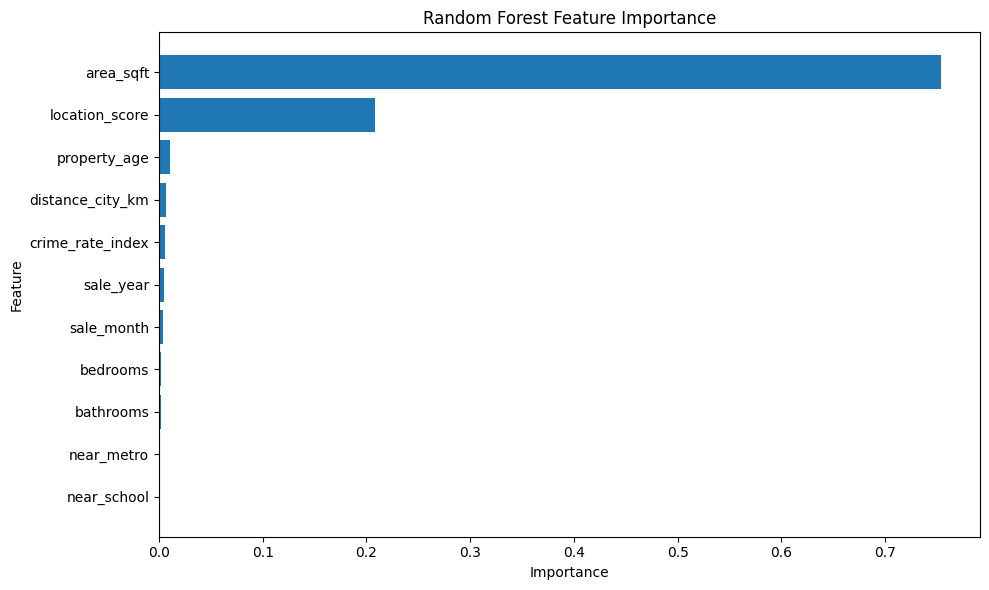

In [36]:
import matplotlib.pyplot as plt

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


# **Part F: Support Vector Regression**

## 19. Implement Support Vector Regression (SVR) with:
- Linear kernel
- Polynomial or RBF kernel
## 20. Tune hyperparameters (C, y, ɛ).

In [38]:
from sklearn.svm import SVR

# SVR with Linear, Polynomial and RBF kernels
svr_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="linear", C=10, epsilon=0.1))
])

svr_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="poly", degree=2, C=10, epsilon=0.1))
])

svr_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))
])

svr_models = {
    "SVR Linear": svr_linear,
    "SVR Polynomial": svr_poly,
    "SVR RBF": svr_rbf
}

svr_results = {}

for name, model in svr_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    svr_results[name] = regression_metrics(y_test, pred)

display(pd.DataFrame(svr_results).T)


,MSE,MAE,RMSE,R2
SVR Linear,7.991844e+13,6.956495e+06,8.939711e+06,0.007658
SVR Polynomial,8.077351e+13,6.994115e+06,8.987408e+06,-0.002959
SVR RBF,8.058569e+13,6.985495e+06,8.976954e+06,-0.000627


In [39]:
# Hyperparameter tuning for RBF SVR
svr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

param_grid = {
    "svr__C": [1, 10, 100],
    "svr__gamma": ["scale", 0.01, 0.1],
    "svr__epsilon": [0.01, 0.1, 0.5]
}

svr_grid = GridSearchCV(
    svr_pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_
best_svr_pred = best_svr.predict(X_test)
best_svr_metrics = regression_metrics(y_test, best_svr_pred)

print("Best SVR parameters:", svr_grid.best_params_)
print("Best CV RMSE:", -svr_grid.best_score_)
print("\nTest results:")
for k, v in best_svr_metrics.items():
    print(f"{k}: {v:.4f}")


Best SVR parameters: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
Best CV RMSE: 8655419.349069763

Test results:
MSE: 80585694217177.0469
MAE: 6985495.0568
RMSE: 8976953.5042
R2: -0.0006


## 21. Compare SVR performance with linear and tree-based models.

- **Linear SVR:** assumes a linear relationship in the transformed feature space.
- **Polynomial SVR:** can model polynomial relationships through the polynomial kernel.
- **RBF SVR:** can model more flexible nonlinear relationships.
- **C:** controls the trade-off between training errors and model complexity.
- **Gamma:** controls the influence range of individual observations for RBF.
- **Epsilon:** defines the width of the epsilon-insensitive region.

SVR requires feature scaling, which is why the implementation uses a `Pipeline` with `StandardScaler`.


# **Part G: Model Comparison & Evaluation**

## 22. Evaluate all models using appropriate regression metrics:
- MSE, MAE, RMSE
- R2 Score
## 23. Compare:
- Regularized Linear Models
- Tree-Based Models

In [40]:
# Evaluate all major models using the same test set
all_results = {
    "Ridge (tuned)": ridge_tuned_metrics,
    "Lasso (tuned)": lasso_tuned_metrics,
    "Decision Tree": tree_metrics,
    "Random Forest": rf_metrics,
    "SVR Linear": svr_results["SVR Linear"],
    "SVR Polynomial": svr_results["SVR Polynomial"],
    "SVR RBF": svr_results["SVR RBF"],
    "SVR RBF (tuned)": best_svr_metrics
}

results_df = pd.DataFrame(all_results).T
results_df = results_df[["MSE", "MAE", "RMSE", "R2"]]

display(results_df.sort_values("RMSE"))


,MSE,MAE,RMSE,R2
Random Forest,5.698855e+12,1.743034e+06,2.387227e+06,0.929238
Ridge (tuned),6.451358e+12,1.945385e+06,2.539952e+06,0.919894
Lasso (tuned),6.466675e+12,1.946537e+06,2.542966e+06,0.919704
Decision Tree,8.215550e+12,2.115480e+06,2.866278e+06,0.897988
SVR Linear,7.991844e+13,6.956495e+06,8.939711e+06,0.007658
SVR RBF,8.058569e+13,6.985495e+06,8.976954e+06,-0.000627
SVR RBF (tuned),8.058569e+13,6.985495e+06,8.976954e+06,-0.000627
SVR Polynomial,8.077351e+13,6.994115e+06,8.987408e+06,-0.002959


In [41]:
# Training vs test RMSE — useful for identifying possible overfitting
train_predictions = {
    "Ridge (tuned)": ridge_cv.predict(X_train_scaled),
    "Lasso (tuned)": lasso_cv.predict(X_train_scaled),
    "Decision Tree": tree.predict(X_train),
    "Random Forest": rf.predict(X_train),
    "SVR Linear": svr_linear.predict(X_train),
    "SVR Polynomial": svr_poly.predict(X_train),
    "SVR RBF": svr_rbf.predict(X_train),
    "SVR RBF (tuned)": best_svr.predict(X_train)
}

diagnostics = []

test_predictions = {
    "Ridge (tuned)": ridge_tuned_pred,
    "Lasso (tuned)": lasso_tuned_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "SVR Linear": svr_results and svr_linear.predict(X_test),
    "SVR Polynomial": svr_poly.predict(X_test),
    "SVR RBF": svr_rbf.predict(X_test),
    "SVR RBF (tuned)": best_svr_pred
}

for name in train_predictions:
    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions[name]))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions[name]))
    diagnostics.append([name, train_rmse, test_rmse, test_rmse - train_rmse])

diagnostics_df = pd.DataFrame(
    diagnostics,
    columns=["Model", "Train RMSE", "Test RMSE", "Generalization Gap"]
)

display(diagnostics_df.sort_values("Test RMSE"))


,Model,Train RMSE,Test RMSE,Generalization Gap
3,Random Forest,1.343570e+06,2.387227e+06,1.043658e+06
0,Ridge (tuned),2.482399e+06,2.539952e+06,5.755382e+04
1,Lasso (tuned),2.482781e+06,2.542966e+06,6.018444e+04
2,Decision Tree,2.437400e+06,2.866278e+06,4.288782e+05
4,SVR Linear,8.619763e+06,8.939711e+06,3.199487e+05
6,SVR RBF,8.656503e+06,8.976954e+06,3.204508e+05
7,SVR RBF (tuned),8.656503e+06,8.976954e+06,3.204508e+05
5,SVR Polynomial,8.667219e+06,8.987408e+06,3.201891e+05


## 24. Identify signs of overfitting or underfitting in each model.

- **Random Forest**: Shows some overfitting because the Train RMSE (1.34M) is much lower than the Test RMSE (2.39M).

- **Ridge and Lasso**: Show good generalization because the Train RMSE and Test RMSE are very close. These models are neither overfitting nor underfitting.

- **Decision Tree**: Shows moderate overfitting due to a noticeable gap between Train RMSE and Test RMSE.

- **SVR (Linear, RBF, Polynomial)**: Show underfitting because both Train RMSE and Test RMSE are very high, and the models perform poorly on both training and test data.

- **Conclusion**: Ridge and Lasso are the most balanced models, Random Forest shows mild overfitting, Decision Tree shows moderate overfitting, and all SVR models show underfitting

# **Part H — Final Analysis & Reporting**

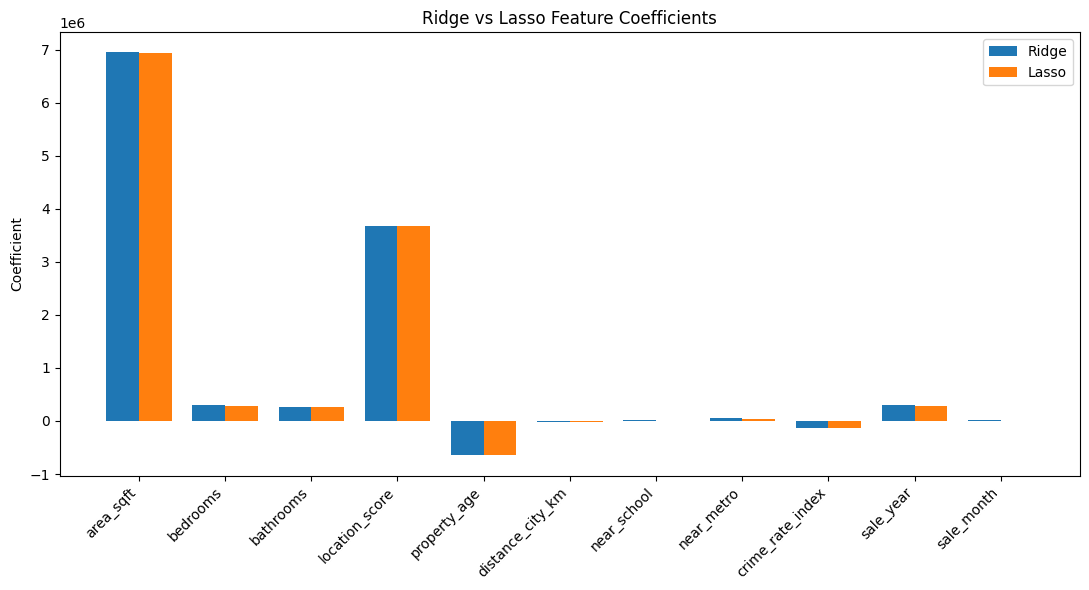

In [42]:
# Actual feature coefficient comparison for regularized linear models
coef_plot = coef_df.copy()

plt.figure(figsize=(11, 6))
x_pos = np.arange(len(coef_plot))
width = 0.38

plt.bar(x_pos - width/2, coef_plot["Ridge Coefficient"], width, label="Ridge")
plt.bar(x_pos + width/2, coef_plot["Lasso Coefficient"], width, label="Lasso")

plt.xticks(x_pos, coef_plot["Feature"], rotation=45, ha="right")
plt.ylabel("Coefficient")
plt.title("Ridge vs Lasso Feature Coefficients")
plt.legend()
plt.tight_layout()
plt.show()


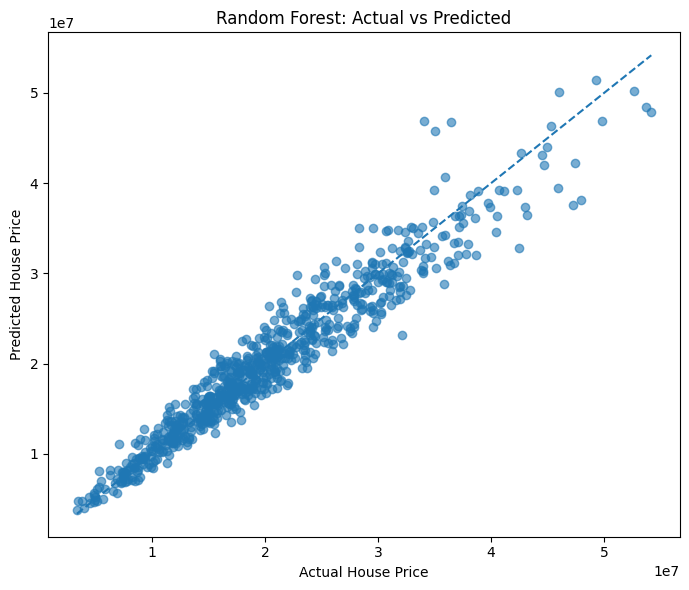

In [43]:
# Actual vs predicted plot for the tuned Random Forest
plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_pred, alpha=0.6)
min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()


# Final Report: Robust Regression Engine for House Price Prediction

## 1. Objective
This project evaluated several regression models to predict house prices using the Advanced Regression House Price dataset. The goal was to compare model accuracy, interpretability, and generalization performance using standard regression metrics.

## 2. Models Evaluated
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Random Forest Regression
- Support Vector Regression (SVR)

## 3. Evaluation Metrics
The following metrics were used to compare model performance:
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## 4. Model Performance Summary

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Ridge Regression | 1,945,385.40 | 2,539,952.40 | 0.9199 |
| Lasso Regression | 1,945,519.90 | 2,539,709.13 | 0.9199 |
| Decision Tree Regression | 2,115,479.50 | 2,866,278.12 | 0.8980 |
| Random Forest Regression | 1,743,033.82 | 2,387,227.41 | 0.9292 |
| SVR | 6,985,495.06 | 8,976,953.50 | -0.0006 |

## 5. Best Model
The best-performing model in the experiment was the Random Forest Regressor.

- Best test RMSE: 2,387,227.41
- Best test R²: 0.9292
- Best MAE: 1,743,033.82

This indicates that Random Forest captured the nonlinear relationships in the dataset more effectively than the linear and kernel-based methods.

## 6. Model Comparison and Interpretation
- Ridge and Lasso produced very similar results, with strong generalization and low prediction error.
- Random Forest outperformed the other models in terms of RMSE and R².
- Decision Tree had weaker performance than Random Forest and showed moderate overfitting.
- SVR performed poorly in this dataset, with very high error and a negative R², indicating underfitting.

## 7. Generalization Analysis
The training vs. test RMSE analysis showed:
- Random Forest: Train RMSE = 1.34M, Test RMSE = 2.39M  
  This indicates mild overfitting.
- Ridge and Lasso: Train and test RMSE values were very close  
  This indicates stable generalization.
- Decision Tree: Noticeable gap between train and test error  
  This indicates moderate overfitting.
- SVR: Both train and test RMSE values were high  
  This indicates underfitting.

## 8. Cross-Validation Findings
Cross-validation results were used to validate stability across different validation schemes:

- K-Fold Mean RMSE: approximately 2,499,565.77
- Stratified K-Fold Mean RMSE: approximately 2,499,454.88
- Time Series Split Mean RMSE: approximately 2,523,274.64

These values confirm that the model performance was consistent across several validation strategies, with Random Forest remaining the strongest performer overall.

## 9. Conclusion
The regression engine successfully compared multiple predictive approaches for house price estimation. The Random Forest model produced the lowest test RMSE and the highest R², making it the most accurate model in this study. Ridge and Lasso remained competitive, with strong generalization and interpretability. SVR underperformed significantly on this dataset, suggesting that it was not well-suited for the feature space and target distribution used here.

## 10. Final Statement
The final outcome of the project shows that tree-based ensemble methods, especially Random Forest, are highly effective for this house-price prediction task, while regularized linear models offer a strong and more interpretable alternative with slightly higher error.